In [1]:
#Import packages 

import numpy as np 
import geopandas as gpd 
import matplotlib.pyplot as plt 
# from matplotlib.colors import ListedColormap
import matplotlib.colors as mcolors
import pandas as pd 
from shapely.geometry import shape 
import json 
from shapely import wkt 
from shapely.geometry import Point
from shapely.geometry import box
from math import cos, radians
from matplotlib.colors import Normalize
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.cm import ScalarMappable
import seaborn as sns 
import matplotlib
from statsmodels.tsa.seasonal import seasonal_decompose

import glob
import os
import csv
import ast

from scipy.stats import chi2_contingency
from math import sqrt
import matplotlib.ticker as mticker

### Reading Temp & Precip (6km) 

In [2]:
temp_all = pd.read_csv('/home/kdonkor_umass_edu/Co-occurrence_Rev2/temp_all_years_6km_buffer.csv').drop(columns = ['Unnamed: 0'])
temp_all['time'] = pd.to_datetime(temp_all['time'])

precip_all = pd.read_csv('/home/kdonkor_umass_edu/Co-occurrence_Rev2/precip_all_years_6km_buffer.csv').drop(columns = ['Unnamed: 0'])
precip_all['time'] = pd.to_datetime(precip_all['time'])

### Wind (6km) 

In [3]:
hourly_wind_df = pd.read_csv('/home/kdonkor_umass_edu/Interpolation/ea_hourly_wind_avg_6km.csv').drop(columns=['Unnamed: 0'])

hourly_wind_df['Timestamp'] = pd.to_datetime(hourly_wind_df['Timestamp'])
hourly_wind_df = hourly_wind_df.rename(columns = {'Timestamp':'time'})
hourly_wind_df['Date'] = hourly_wind_df['time'].dt.date

### Lightning (6km) 

In [4]:
hourly_lightning_df = pd.read_csv('/home/kdonkor_umass_edu/Interpolation/ea_hourly_lightning_avg_6km_buffer_aligned.csv').drop(columns=['Unnamed: 0'])

hourly_lightning_df['Timestamp'] = pd.to_datetime(hourly_lightning_df['Timestamp'])
hourly_lightning_df = hourly_lightning_df.rename(columns = {'Timestamp':'time'})

hourly_lightning_df['Date'] = hourly_lightning_df['time'].dt.date

### Extreme Definitions 

### Temp 

In [5]:
# temp_all['Temp'].quantile(0.95)

In [6]:
temp_all['Date'] = temp_all['time'].dt.floor('D')

# Hot hour flag
temp_all['Hot_Hour'] = temp_all['Temp'] > 32

# Group by EA and Date, and count Hot_Hour sum
daily_hot_hours = (
    temp_all.groupby(['ea_code9ch', 'Date'], as_index=False)
            .agg({'Hot_Hour': 'sum'})
)

daily_hot_hours = daily_hot_hours.rename(columns={'Hot_Hour': 'Num_Hot_Hours'})

### Precip 

In [7]:
precip_all['Date'] = precip_all['time'].dt.floor('D')  

# Group by EA and Date, sum Precip
daily_precip = (
    precip_all.groupby(['ea_code9ch', 'Date'], as_index=False)
      .agg({'Precip': 'sum'})
)

### Wind 

In [8]:
# Windy hour flag
hourly_wind_df['Windy_Hour'] = hourly_wind_df['Wind Gusts (m/s)'] > 5.93

# Group by EA and Date, and count Windy_Hour sum
daily_windy_hours = (
    hourly_wind_df.groupby(['ea_code9ch', 'Date'], as_index=False)
            .agg({'Windy_Hour': 'sum'})
)

daily_windy_hours = daily_windy_hours.rename(columns={'Windy_Hour': 'Num_Windy_Hours'})

### Lightning 

In [9]:
daily_lightning_per_ea = hourly_lightning_df.groupby(['ea_code9ch', 'Date'])['Lightning Events'].sum().reset_index()

## Percentiles 

In [10]:
### 90th pct 
hot_hrs_90_thresh = daily_hot_hours['Num_Hot_Hours'].quantile(0.90)
temp_90_thresh = temp_all['Temp'].quantile(0.90)

precip_90_thresh = daily_precip['Precip'].quantile(0.90)
lightning_90_thresh = daily_lightning_per_ea['Lightning Events'].quantile(0.90)

windy_hrs_90_thresh = daily_windy_hours['Num_Windy_Hours'].quantile(0.90)
wind_90_thresh = hourly_wind_df['Wind Gusts (m/s)'].quantile(0.90)


### 95th pct 

hot_hrs_95_thresh = daily_hot_hours['Num_Hot_Hours'].quantile(0.95)
temp_95_thresh = temp_all['Temp'].quantile(0.95)
precip_95_thresh = daily_precip['Precip'].quantile(0.95)
lightning_95_thresh = daily_lightning_per_ea['Lightning Events'].quantile(0.95)
windy_hrs_95_thresh = daily_windy_hours['Num_Windy_Hours'].quantile(0.95)
wind_95_thresh = hourly_wind_df['Wind Gusts (m/s)'].quantile(0.95)

### 99th pct 
hot_hrs_99_thresh = daily_hot_hours['Num_Hot_Hours'].quantile(0.99)
temp_99_thresh = temp_all['Temp'].quantile(0.99)
precip_99_thresh = daily_precip['Precip'].quantile(0.99)
lightning_99_thresh = daily_lightning_per_ea['Lightning Events'].quantile(0.99)
windy_hrs_99_thresh = daily_windy_hours['Num_Windy_Hours'].quantile(0.99)
wind_99_thresh = hourly_wind_df['Wind Gusts (m/s)'].quantile(0.99)

#### Dictionary for percentiles 

In [11]:
# Percentile Threshold dictionaries 
temp_thresh_dict = {
    '90': temp_90_thresh.round(2),
    '95': temp_95_thresh.round(2),
    '99': temp_99_thresh.round(2)
}

hot_hrs_thresh_dict = {
    '90': hot_hrs_90_thresh.round(2),
    '95': hot_hrs_95_thresh.round(2),
    '99': hot_hrs_99_thresh.round(2)
}

precip_thresh_dict = {
    '90': precip_90_thresh.round(2),
    '95': precip_95_thresh.round(2),
    '99': precip_99_thresh.round(2)
}

wind_thresh_dict = {
    '90': wind_90_thresh.round(2),
    '95': wind_95_thresh.round(2),
    '99': wind_99_thresh.round(2)
}

windy_hrs_thresh_dict = {
    '90': windy_hrs_90_thresh.round(2),
    '95': windy_hrs_95_thresh.round(2),
    '99': windy_hrs_99_thresh.round(2)
}

lightning_thresh_dict = {
    '90': 1,   # at least 1 lightning strike 
    '95': lightning_95_thresh.round(2),
    '99': lightning_99_thresh.round(2)
}

## --- Aligning all weather dfs --- 

In [12]:
def prepare_hourly_df_TPLW_n_outage_data_REV(ea_row, 
                                         temp_df, 
                                         precip_df, 
                                         lightning_df, 
                                         wind_df, 
                                         pqr_df, 
                                         outage_threshold, 
                                         contained_flag = False):
    ea = ea_row['ea_code9ch']
    site_list = ea_row['Intersecting_Sites']

    all_merged = []

    for site_id in site_list:
        site_id = int(site_id)

        # Filter temperature
        temp_filt = (
            temp_df[temp_df['ea_code9ch'] == ea]
            .reset_index(drop=True)
            .drop(columns=['geometry'], errors='ignore')
        )
        if 'Hot_Hour' in temp_filt.columns:
            temp_filt = temp_filt.drop(columns=['Hot_Hour'])

        temp_filt['time'] = temp_filt['time'].astype('datetime64[ns]')

        # Filter precipitation
        precip_filt = (
            precip_df[precip_df['ea_code9ch'] == ea]
            .reset_index(drop=True)
            .drop(columns=['geometry'], errors='ignore')
        )
        precip_filt['time'] = precip_filt['time'].astype('datetime64[ns]')
        precip_filt = precip_filt[['time', 'Precip']]

        # Merge temp and precip
        merged = temp_filt.merge(precip_filt, on='time', how='outer')

        # Filter lightning and outer join
        lightning_filt = (
            lightning_df[lightning_df['ea_code9ch'] == ea]
            .reset_index(drop=True)
            .drop(columns=['geometry'], errors='ignore')
            [['time', 'Lightning Events']]
        )
        merged = merged.merge(lightning_filt, on='time', how='outer')
        merged['Lightning Events'] = merged['Lightning Events'].fillna(0)

        ## Merge with Wind (inner merge) 
        wind_filt = (
            wind_df[wind_df['ea_code9ch'] == ea]
            .reset_index(drop=True)
            .drop(columns=['geometry'], errors='ignore')
        )
        wind_filt = wind_filt[['time', 'Wind Gusts (m/s)']]  
        wind_filt['time'] = wind_filt['time'].astype('datetime64[ns]')

        merged = merged.merge(wind_filt, on='time', how='inner')
     
        # Filter outage data and flag
        pqr_filt = (
            pqr_df[pqr_df['site_id'] == site_id]
            .reset_index(drop=True)[['time', 'site_id', 'outage_events', 'outage_mins']]
        )

        if contained_flag == True: 
            flagged_outages = flag_outage_hours_rev1(pqr_filt, threshold=outage_threshold)   #### 1 to 2/4 hours 
        else: 
            flagged_outages = flag_outage_hours(pqr_filt, threshold=outage_threshold)  #### 8+ hours 

        # Inner join outages
        merged = merged.merge(flagged_outages, on='time', how='inner')

        # Add identifiers
        merged['ea_code9ch'] = ea
        merged['site_id'] = site_id

        # Reorder columns
        merged = merged[['time', 'Date', 'ea_code9ch', 'site_id', 'Temp', 'Precip', 
                 'Lightning Events', 'Wind Gusts (m/s)', 
                 'Outage_Flag', 'Outage_Dur']]

        all_merged.append(merged)

    return pd.concat(all_merged, ignore_index=True)

In [13]:
def flag_outage_hours(df, threshold):
    
    df = df.copy()
    df['Outage_Flag'] = df['outage_mins'] >= threshold
    df['Outage_Dur'] = round( (threshold/60), 2)
    df = df[['time', 'site_id', 'Outage_Flag', 'Outage_Dur']]
    
    return df

### EAs n Sites - using new 'EAs_n_Sites' (6km) 

In [14]:
merged_eas_sites = pd.read_csv('/home/kdonkor_umass_edu/Co-occurrence_Rev2/ea_site_list_6km_buffer.csv')
merged_eas_sites = merged_eas_sites[['ea_code9ch', 'Intersecting_Sites']]

# Convert the string representation of lists to actual lists
merged_eas_sites['Intersecting_Sites'] = merged_eas_sites['Intersecting_Sites'].apply(ast.literal_eval)

filtered_eas_sites_copy = merged_eas_sites

filtered_eas_sites_copy_r1 = filtered_eas_sites_copy.copy()

### PQR hourly data

In [15]:
## 22 
pqr_hourly_22 = pd.read_csv('/work/pi_jtaneja_umass_edu/kdonkor_umass_edu/Geospatial_Files/2022/merged_outage_n_voltage_hourly_22_NEW.csv')
pqr_hourly_22['time'] = pd.to_datetime(pqr_hourly_22['time'])
pqr_hourly_22['time'] = pqr_hourly_22['time'].dt.tz_convert(None)

## 23 
pqr_hourly_23 = pd.read_csv('/work/pi_jtaneja_umass_edu/kdonkor_umass_edu/Geospatial_Files/2023/merged_outage_n_voltage_hourly_23_NEW.csv')
pqr_hourly_23['time'] = pd.to_datetime(pqr_hourly_23['time'])
pqr_hourly_23['time'] = pqr_hourly_23['time'].dt.tz_convert(None)

pqr_hourly_all = pd.concat([pqr_hourly_22, pqr_hourly_23], ignore_index=True).drop(columns=['Unnamed: 0'])
pqr_hourly_all['site_id'].nunique()

366

### Remove sites with > `10%` missing data & less than 24 months 

In [16]:
sites_to_omit = pd.read_csv('/work/pi_jtaneja_umass_edu/kdonkor_umass_edu/complete_site_removal_df.csv')['site_id'].to_list()

pqr_hourly_all_rev = pqr_hourly_all[ ~( pqr_hourly_all['site_id'].isin(sites_to_omit) ) ].reset_index(drop=True)

In [17]:
## Outage Duration & Percentile 
dur = 60  # duration in minutes --> doesn't matter here, just focused on the weather variables 
percentile = '95'

# Main loop
results = []

for _, row in filtered_eas_sites_copy_r1.iterrows():
    merged_hourly = prepare_hourly_df_TPLW_n_outage_data_REV(
        row, 
        temp_all, 
        precip_all, 
        hourly_lightning_df, 
        hourly_wind_df, 
        pqr_hourly_all_rev, 
        outage_threshold=dur
    )
    if merged_hourly is not None:
        results.append(merged_hourly)

merged_hourly_data_global = pd.concat(results, ignore_index=True)

In [18]:
hourly_weather = merged_hourly_data_global.drop(columns=['Outage_Flag', 'Outage_Dur', 'site_id'])

hourly_weather['ea_code9ch'].nunique()

214

## Precip CDF 

In [19]:
from matplotlib.ticker import PercentFormatter
import numpy as np
import matplotlib.pyplot as plt

def plot_precip_cdf(
    df,
    precip_col='Precip',
    xlim=None,
    ylim=None,
    figsize=(8,6),
    linewidth=2,
    cdf_color='blue',
    grid_alpha=0.3,
    xlabel='Daily Precipitation (mm)',
    ylabel='Proportion of Days',
    x_label_size=16,
    y_label_size=16,
    x_label_weight='bold',
    y_label_weight='bold',
    x_labelpad=15,   # NEW: padding for x-label
    y_labelpad=15,   # NEW: padding for y-label
    x_ticks_size=14,
    y_ticks_size=14,
    spine_width=1.5,
    vlines=None,
    marker_points=None,   
    marker_colors=None,
    marker_style='o',
    marker_size=6,
    legend_size=14,
    legend_loc='best', 
    legend_bbox=(1.0, 1.0)
):
    """
    Plot CDF of daily precipitation with optional vertical lines and markers at specific x-points,
    with custom colors for each marker, formatted axes, and hidden top/right spines.
    """
    
    # Sort precipitation values
    precip_values = np.sort(df[precip_col].values)
    proportion = np.arange(1, len(precip_values)+1) / len(precip_values)
    
    fig, ax = plt.subplots(figsize=figsize)
    
    # Plot CDF line
    ax.plot(precip_values, proportion, color=cdf_color, linewidth=linewidth)
    
    # Add markers at specified x-points
    if marker_points:
        if marker_colors is None:
            marker_colors = ['black'] * len(marker_points)
        for x_pt, color in zip(marker_points, marker_colors):
            y_pt = proportion[np.abs(precip_values - x_pt).argmin()]
            ax.plot(x_pt, y_pt, marker=marker_style, color=color, markersize=marker_size)
    
    # Add vertical lines if provided
    if vlines:
        for line in vlines:
            ax.axvline(
                x=line.get('x'),
                color=line.get('color', 'black'),
                linestyle=line.get('linestyle', '--'),
                linewidth=line.get('linewidth', 1.8),
                label=line.get('label')
            )
    
    # Axis labels with increased padding
    ax.set_xlabel(xlabel, fontsize=x_label_size, fontweight=x_label_weight, labelpad=x_labelpad)
    ax.set_ylabel(ylabel, fontsize=y_label_size, fontweight=y_label_weight, labelpad=y_labelpad)
    
    if xlim: ax.set_xlim(xlim)
    if ylim: ax.set_ylim(ylim)
    
    # Grid
    ax.grid(True, alpha=grid_alpha)
    
    # Ticks
    ax.tick_params(axis='x', labelsize=x_ticks_size, width=spine_width)
    ax.tick_params(axis='y', labelsize=y_ticks_size, width=spine_width)
    
    # Spine formatting
    for spine in ax.spines.values():
        spine.set_linewidth(spine_width)
    
    # Hide top and right spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # y-axis as percentage
    ax.yaxis.set_major_formatter(PercentFormatter(1.0))
    
    # Legend formatting
    ax.legend(fontsize=legend_size, loc=legend_loc, bbox_to_anchor=legend_bbox, frameon=True, framealpha=0.9)
    
    plt.show()

In [20]:
from matplotlib.ticker import PercentFormatter
import numpy as np
import matplotlib.pyplot as plt

def plot_precip_cdf(
    df,
    precip_col='Precip',
    xlim=None,
    ylim=None,
    figsize=(8,6),
    linewidth=2,
    cdf_color='blue',
    grid_alpha=0.3,
    xlabel='Daily Precipitation (mm)',
    ylabel='Proportion of Days',
    x_label_size=16,
    y_label_size=16,
    x_label_weight='bold',
    y_label_weight='bold',
    x_labelpad=15,
    y_labelpad=15,
    x_ticks_size=14,
    y_ticks_size=14,
    spine_width=1.5,
    vlines=None,
    marker_points=None,   
    marker_colors=None,
    marker_style='o',
    marker_size=6,
    legend_size=14,
    legend_loc='best', 
    legend_bbox=(1.0, 1.0),
    save_path=None,           # NEW
    dpi=300                   # NEW
):
    """
    Plot CDF of daily precipitation with optional vertical lines and markers at specific x-points,
    with custom colors for each marker, formatted axes, hidden top/right spines, and optional saving.
    """
    
    # Sort precipitation values
    precip_values = np.sort(df[precip_col].values)
    proportion = np.arange(1, len(precip_values)+1) / len(precip_values)
    
    fig, ax = plt.subplots(figsize=figsize)
    
    # Plot CDF line
    ax.plot(precip_values, proportion, color=cdf_color, linewidth=linewidth)
    
    # Add markers
    if marker_points:
        if marker_colors is None:
            marker_colors = ['black'] * len(marker_points)
        for x_pt, color in zip(marker_points, marker_colors):
            y_pt = proportion[np.abs(precip_values - x_pt).argmin()]
            ax.plot(x_pt, y_pt, marker=marker_style, color=color, markersize=marker_size)
    
    # Add vertical lines
    if vlines:
        for line in vlines:
            ax.axvline(
                x=line.get('x'),
                color=line.get('color', 'black'),
                linestyle=line.get('linestyle', '--'),
                linewidth=line.get('linewidth', 1.8),
                label=line.get('label')
            )
    
    # Axis labels
    ax.set_xlabel(xlabel, fontsize=x_label_size, fontweight=x_label_weight, labelpad=x_labelpad)
    ax.set_ylabel(ylabel, fontsize=y_label_size, fontweight=y_label_weight, labelpad=y_labelpad)
    
    if xlim: ax.set_xlim(xlim)
    if ylim: ax.set_ylim(ylim)
    
    # Grid
    ax.grid(True, alpha=grid_alpha)
    
    # Ticks
    ax.tick_params(axis='x', labelsize=x_ticks_size, width=spine_width)
    ax.tick_params(axis='y', labelsize=y_ticks_size, width=spine_width)
    
    # Spine formatting
    for spine in ax.spines.values():
        spine.set_linewidth(spine_width)
    
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # Format y-axis as percentage
    ax.yaxis.set_major_formatter(PercentFormatter(1.0))
    
    # Legend
    ax.legend(fontsize=legend_size, loc=legend_loc, bbox_to_anchor=legend_bbox,
              frameon=True, framealpha=0.9)
    
    # Save figure if path provided
    if save_path:
        plt.savefig(save_path, dpi=dpi, bbox_inches='tight')
    
    plt.show()

## Daily Precip 

In [21]:
precip_214_eas_df = hourly_weather.copy().drop(columns = ['Temp', 'Lightning Events', 'Wind Gusts (m/s)'])
precip_214_eas_df['Date'] = precip_214_eas_df['time'].dt.floor('D')  

# Group by EA and Date, sum Precip
daily_precip_214_eas = (
    precip_214_eas_df.groupby(['ea_code9ch', 'Date'], as_index=False)
      .agg({'Precip': 'sum'})
)

In [104]:
# plot_precip_cdf(
#     daily_precip_214_eas,
#     precip_col='Precip',
#     xlim=(-3, 120),
#     ylim=(0.7,1.02),
#     figsize=(10,8),
#     linewidth=2,
#     grid_alpha=0.5,
#     xlabel='Daily Precipitation (mm)',
#     ylabel='Proportion of Days',
#     x_ticks_size=12,
#     y_ticks_size=12,
#     x_label_weight='bold',
#     y_label_weight='bold', 
#     vlines=[
#         {'x': 17.01, 'color':'red', 'linestyle':'--', 'label':'95th percentile - daily (17.01 mm)'},
#         {'x': 53.59, 'color':'blue', 'linestyle':':', 'label':'99th percentile - daily (53.59 mm)'}
#     ], 
#     legend_size=16,
#     legend_loc='upper left', 
#     legend_bbox=(0.50, 0.78), 
#     marker_points=[17.01, 53.59],  
#     marker_colors=['red','blue'],
#     marker_style='o',
#     marker_size=8,
#     save_path='/home/kdonkor_umass_edu/Co-occurrence_Rev2/supplementary_plots/daily_precip.png'
# )

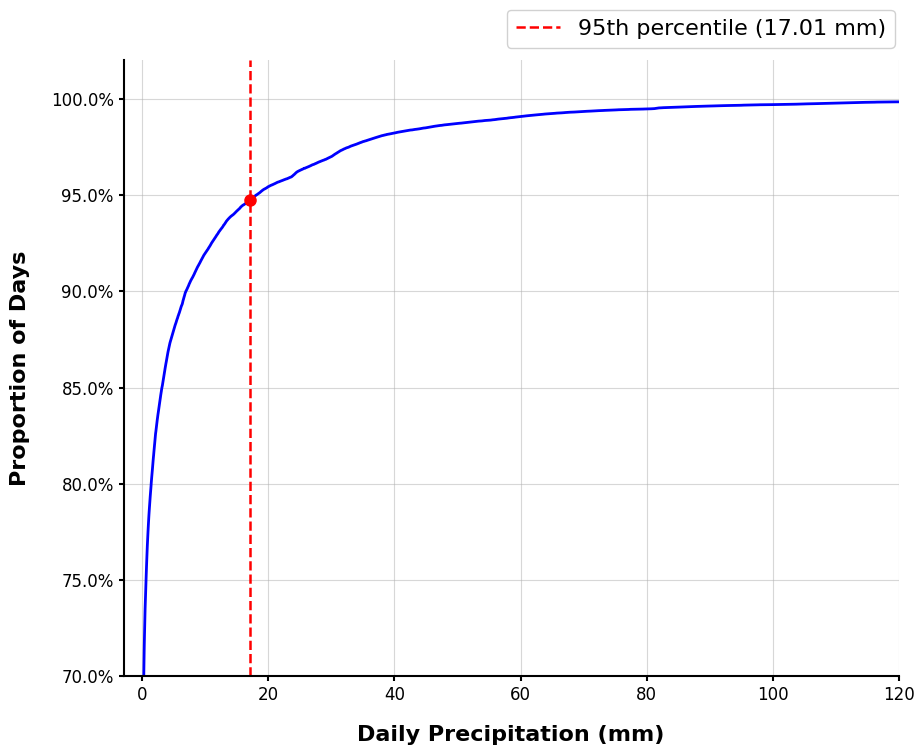

In [112]:
plot_precip_cdf(
    daily_precip_214_eas,
    precip_col='Precip',
    xlim=(-3, 120),
    ylim=(0.7,1.02),
    figsize=(10,8),
    linewidth=2,
    grid_alpha=0.5,
    xlabel='Daily Precipitation (mm)',
    ylabel='Proportion of Days',
    x_ticks_size=12,
    y_ticks_size=12,
    x_label_weight='bold',
    y_label_weight='bold', 
    vlines=[
        {'x': 17.01, 'color':'red', 'linestyle':'--', 'label':'95th percentile (17.01 mm)'},
        # {'x': 53.59, 'color':'blue', 'linestyle':':', 'label':'99th percentile - daily (53.59 mm)'}
    ], 
    legend_size=16,
    legend_loc='upper left', 
    legend_bbox=(0.48, 1.10), 
    marker_points=[17.01],  
    marker_colors=['red'],
    marker_style='o',
    marker_size=8,
    save_path='/home/kdonkor_umass_edu/Co-occurrence_Rev2/supplementary_plots/daily_precip.png'
)

### Daily Stats 

In [23]:
num_days_95 = daily_precip_214_eas[daily_precip_214_eas['Precip'] >= precip_thresh_dict['95']]
num_days_99 = daily_precip_214_eas[daily_precip_214_eas['Precip'] >= precip_thresh_dict['99']]

In [24]:
print(f"Total number of days is {len(daily_precip_214_eas):,.0f}\n")
print(f"Number of days with daily precip >= 95th percentile is {len(num_days_95):,.0f}")
print(f"Number of days with daily precip >= 99th percentile is {len(num_days_99):,.0f}")

Total number of days is 155,254

Number of days with daily precip >= 95th percentile is 8,155
Number of days with daily precip >= 99th percentile is 1,786


In [25]:
percent_precip_days_95 = len(num_days_95)*100/len(daily_precip_214_eas)
percent_precip_days_95

5.252682700606748

## Hourly Precip 

In [113]:
# plot_precip_cdf(
#     hourly_weather,
#     precip_col='Precip',
#     xlim=(-1.0, 20),
#     ylim=(0.85,1.02),
#     figsize=(10,8),
#     linewidth=2,
#     grid_alpha=0.5,
#     xlabel='Hourly Precipitation (mm)',
#     ylabel='Proportion of Hours',
#     x_ticks_size=12,
#     y_ticks_size=12,
#     x_label_weight='bold',
#     y_label_weight='bold', 
#     vlines=[
#         {'x': 0.07, 'color':'blue', 'linestyle':'--', 'label':'95th percentile - hourly (0.07 mm)'},
#         {'x': 2.39, 'color':'blue', 'linestyle':':', 'label':'99th percentile - hourly (2.39 mm)'}, 
#         {'x': 8.0, 'color':'red', 'linestyle':'--', 'label':'Heavy rain threshold (8.0 mm)'}, 
#         {'x': 10.0, 'color':'green', 'linestyle':'--', 'label':'Heavy shower threshold (10.0 mm)'}
#     ], 
#     legend_size=16,
#     legend_loc='upper left', 
#     legend_bbox=(0.60, 0.78), 
#     marker_points=[0.07, 2.39, 8, 10],  
#     marker_colors=['blue','blue', 'r', 'g'],
#     marker_style='o',
#     marker_size=8,
#     save_path='/home/kdonkor_umass_edu/Co-occurrence_Rev2/supplementary_plots/hourly_precip.png'
# )

### Hourly Stats 

In [27]:
num_hours_95 = hourly_weather[hourly_weather['Precip'] >= hourly_weather['Precip'].quantile(0.95)]
num_hours_99 = hourly_weather[hourly_weather['Precip'] >= hourly_weather['Precip'].quantile(0.99)]

num_hours_heavy_rain = hourly_weather[hourly_weather['Precip'] >= 8]
num_hours_heavy_shower = hourly_weather[hourly_weather['Precip'] >= 10]

In [28]:
print(f"Total number of hours is {len(hourly_weather):,.0f}\n")
print(f"Number of hours with precip >= 95th percentile is {len(num_hours_95):,.0f}")
print(f"Number of hours with precip >= 99th percentile is {len(num_hours_99):,.0f}")
print(f"Number of hours with precip >= 8mm is {len(num_hours_heavy_rain):,.0f}")
print(f"Number of hours with precip >= 10mm is {len(num_hours_heavy_shower):,.0f}")

Total number of hours is 4,092,070

Number of hours with precip >= 95th percentile is 204,604
Number of hours with precip >= 99th percentile is 40,921
Number of hours with precip >= 8mm is 14,097
Number of hours with precip >= 10mm is 11,289


In [29]:
percent_precip_hrs_heavy_rain = len(num_hours_heavy_rain)*100/len(hourly_weather)
percent_precip_hrs_heavy_rain

0.3444955731451319

In [30]:
percent_precip_hrs_heavy_shwr = len(num_hours_heavy_shower)*100/len(hourly_weather)
percent_precip_hrs_heavy_shwr

0.27587504612579944

## Lightning CDF 

### Daily 

In [31]:
lightning_214_eas_df = hourly_weather.copy().drop(columns = ['Temp', 'Precip', 'Wind Gusts (m/s)'])
daily_lightning_214_eas = lightning_214_eas_df.groupby(['ea_code9ch', 'Date'])['Lightning Events'].sum().reset_index()

In [97]:
# plot_precip_cdf(
#     daily_lightning_214_eas,
#     precip_col='Lightning Events',
#     xlim=(-3, 80),
#     ylim=(0.7,1.02),
#     figsize=(10,8),
#     linewidth=2,
#     grid_alpha=0.5,
#     xlabel='Daily Lightning Events',
#     ylabel='Proportion of Days',
#     x_ticks_size=12,
#     y_ticks_size=12,
#     x_label_weight='bold',
#     y_label_weight='bold', 
#     vlines=[
#         {'x': 6, 'color':'red', 'linestyle':'--', 'label':'95th percentile (6 events)'},
#         {'x': 52, 'color':'blue', 'linestyle':':', 'label':'99th percentile (52 events)'}
#     ], 
#     legend_size=14,
#     legend_loc='upper left', 
#     legend_bbox=(0.55, 1.15), 
#     marker_points=[6, 52],  
#     marker_colors=['red','blue'],
#     marker_style='o',
#     marker_size=8,
#     save_path='/home/kdonkor_umass_edu/Co-occurrence_Rev2/supplementary_plots/daily_lightning.png'
# )

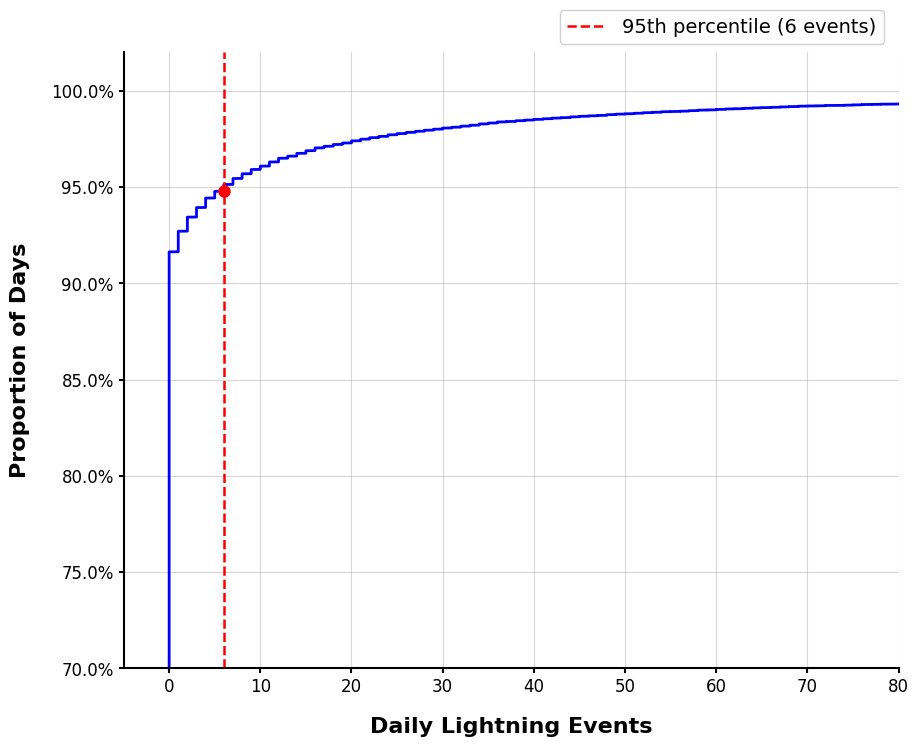

In [156]:
plot_precip_cdf(
    daily_lightning_214_eas,
    precip_col='Lightning Events',
    xlim=(-5, 80),
    ylim=(0.7,1.02),
    figsize=(10,8),
    linewidth=2,
    grid_alpha=0.5,
    xlabel='Daily Lightning Events',
    ylabel='Proportion of Days',
    x_ticks_size=12,
    y_ticks_size=12,
    x_label_weight='bold',
    y_label_weight='bold', 
    vlines=[
        {'x': 6, 'color':'red', 'linestyle':'--', 'label':'95th percentile (6 events)'},
        # {'x': 52, 'color':'blue', 'linestyle':':', 'label':'99th percentile (52 events)'}
    ], 
    legend_size=14,
    legend_loc='upper left', 
    legend_bbox=(0.55, 1.085), 
    marker_points=[6, 52],  
    marker_colors=['red'],
    marker_style='o',
    marker_size=8,
    save_path='/home/kdonkor_umass_edu/Co-occurrence_Rev2/supplementary_plots/daily_lightning.png'
)

### Daily Stats 

In [33]:
num_days_lightning_95 = daily_lightning_214_eas[daily_lightning_214_eas['Lightning Events'] >= lightning_thresh_dict['95']]
num_days_lightning_99 = daily_lightning_214_eas[daily_lightning_214_eas['Lightning Events'] >= lightning_thresh_dict['99']]

In [34]:
print(f"Total number of days is {len(daily_lightning_214_eas):,.0f}\n")
print(f"Number of days with daily lightning >= 95th percentile is {len(num_days_lightning_95):,.0f}")
print(f"Number of days with daily lightning >= 99th percentile is {len(num_days_lightning_99):,.0f}")

Total number of days is 155,254

Number of days with daily lightning >= 95th percentile is 8,094
Number of days with daily lightning >= 99th percentile is 1,802


In [35]:
percent_lightning_days_95 = len(num_days_lightning_95)*100/len(daily_lightning_214_eas)
percent_lightning_days_95

5.213392247542736

In [103]:
# plot_precip_cdf(
#     hourly_weather,
#     precip_col='Lightning Events',
#     xlim=(-0.5, 10),
#     ylim=(0.9,1.02),
#     figsize=(10,8),
#     linewidth=2,
#     grid_alpha=0.5,
#     xlabel='Hourly Lightning Events',
#     ylabel='Proportion of Hours',
#     x_ticks_size=12,
#     y_ticks_size=12,
#     x_label_weight='bold',
#     y_label_weight='bold', 
#     vlines=[
#         {'x': 0, 'color':'blue', 'linestyle':'--', 'label':'95th/99th percentile (0 events)'},
#         {'x': 1, 'color':'orange', 'linestyle':'--', 'label':'1 event'}, 
#         {'x': 2, 'color':'green', 'linestyle':':', 'label':'2 events'}, 

#     ], 
#     legend_size=14,
#     legend_loc='upper left', 
#     legend_bbox=(0.40, 1.18), 
#     marker_points=[0, 0, 1, 2],  
#     marker_colors=['blue','blue', 'orange', 'green'],
#     marker_style='o',
#     marker_size=8,
#     save_path='/home/kdonkor_umass_edu/Co-occurrence_Rev2/supplementary_plots/hourly_lightning.png'
# )

### Hourly Stats 

In [37]:
num_hours_lightning_95 = hourly_weather[hourly_weather['Lightning Events'] >= hourly_weather['Lightning Events'].quantile(0.95)]
num_hours_lightning_99 = hourly_weather[hourly_weather['Lightning Events'] >= hourly_weather['Lightning Events'].quantile(0.99)]
num_hours_lightning_1 = hourly_weather[hourly_weather['Lightning Events'] >= 1]
num_hours_lightning_2 = hourly_weather[hourly_weather['Lightning Events'] >= 2]

In [38]:
print(f"Total number of hours is {len(hourly_weather):,.0f}\n")
print(f"Number of hours with lightning >= 95th percentile is {len(num_hours_lightning_95):,.0f}")
print(f"Number of hours with lightning >= 99th percentile is {len(num_hours_lightning_99):,.0f}")
print(f"Number of hours with lightning >= 1 event is {len(num_hours_lightning_1):,.0f}")
print(f"Number of hours with lightning >= 2 events is {len(num_hours_lightning_2):,.0f}")

Total number of hours is 4,092,070

Number of hours with lightning >= 95th percentile is 4,092,070
Number of hours with lightning >= 99th percentile is 4,092,070
Number of hours with lightning >= 1 event is 28,155
Number of hours with lightning >= 2 events is 22,151


In [39]:
# 24*365*2*214

In [40]:
# 24*365*2*1

In [41]:
percent_hrs_lightning_1 = len(num_hours_lightning_1)*100/len(hourly_weather)
percent_hrs_lightning_1

0.6880380834149954

## Hourly Temp 

In [123]:
# plot_precip_cdf(
#     hourly_weather,
#     precip_col='Temp',
#     xlim=(28, 35),
#     ylim=(0.65,1.02),
#     figsize=(10,8),
#     linewidth=2,
#     grid_alpha=0.5,
#     xlabel='Hourly Temperature (°C)',
#     ylabel='Proportion of Hours',
#     x_ticks_size=12,
#     y_ticks_size=12,
#     x_label_weight='bold',
#     y_label_weight='bold', 
#     vlines=[
#         {'x': 32.16, 'color':'blue', 'linestyle':'--', 'label':'95th percentile - hourly value (32.16°C)'},
#         {'x': 33.27, 'color':'green', 'linestyle':':', 'label':'99th percentile - hourly value (33.27°C)'}, 
#         {'x': 32.0, 'color':'red', 'linestyle':'--', 'label':'WHO thermal comfort (32.0°C)'}, 
#     ], 
#     legend_size=16,
#     legend_loc='upper left', 
#     legend_bbox=(0.77, 0.8), 
#     marker_points=[32.16, 33.27, 32],  
#     marker_colors=['blue','g', 'r'],
#     marker_style='o',
#     marker_size=8,
#     save_path='/home/kdonkor_umass_edu/Co-occurrence_Rev2/supplementary_plots/hourly_temp.png'
# )

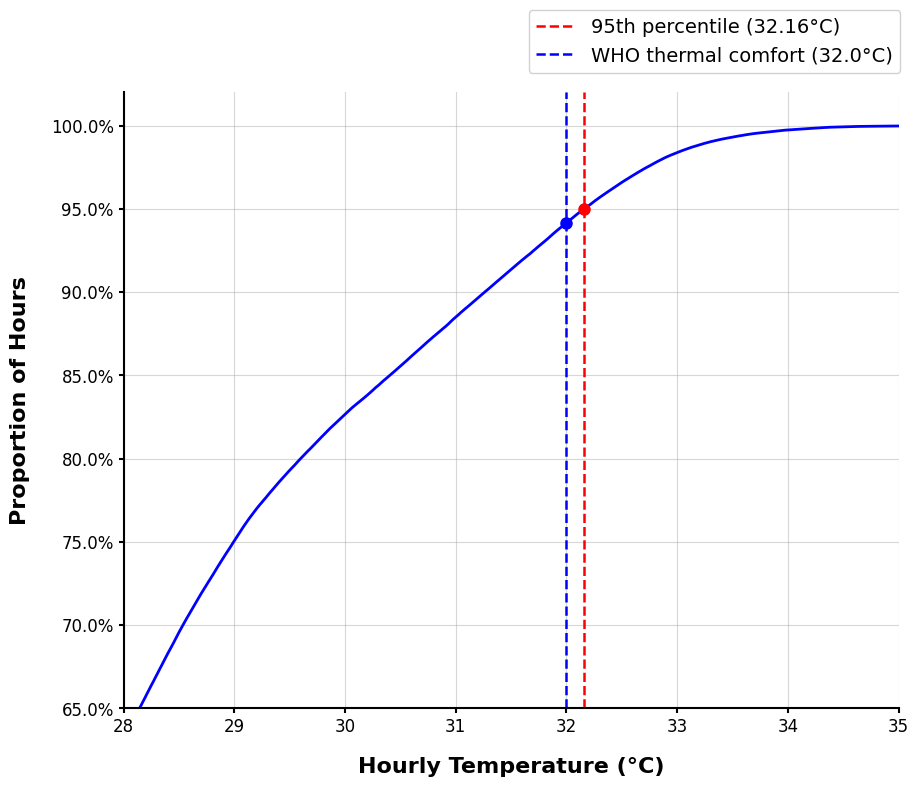

In [137]:
plot_precip_cdf(
    hourly_weather,
    precip_col='Temp',
    xlim=(28, 35),
    ylim=(0.65,1.02),
    figsize=(10,8),
    linewidth=2,
    grid_alpha=0.5,
    xlabel='Hourly Temperature (°C)',
    ylabel='Proportion of Hours',
    x_ticks_size=12,
    y_ticks_size=12,
    x_label_weight='bold',
    y_label_weight='bold', 
    vlines=[
        {'x': 32.16, 'color':'r', 'linestyle':'--', 'label':'95th percentile (32.16°C)'},
        # {'x': 33.27, 'color':'green', 'linestyle':':', 'label':'99th percentile - hourly value (33.27°C)'}, 
        {'x': 32.0, 'color':'blue', 'linestyle':'--', 'label':'WHO thermal comfort (32.0°C)'}, 
    ], 
    legend_size=14,
    legend_loc='upper left', 
    legend_bbox=(0.51, 1.15), 
    marker_points=[32.16, 32],  
    marker_colors=['r', 'blue'],
    marker_style='o',
    marker_size=8,
    save_path='/home/kdonkor_umass_edu/Co-occurrence_Rev2/supplementary_plots/hourly_temp.png'
)

### Hourly Stats 

In [43]:
num_hours_temp_95 = hourly_weather[hourly_weather['Temp'] >= hourly_weather['Temp'].quantile(0.95)]
num_hours_temp_99 = hourly_weather[hourly_weather['Temp'] >= hourly_weather['Temp'].quantile(0.99)]
num_hours_temp_therm_comfort = hourly_weather[hourly_weather['Temp'] >= 32]

In [44]:
print(f"Total number of hours is {len(hourly_weather):,.0f}\n")
print(f"Number of hours with >= 32 deg is {len(num_hours_temp_therm_comfort):,.0f}")
print(f"Number of hours with temp >= 95th percentile is {len(num_hours_temp_95):,.0f}")
print(f"Number of hours with temp >= 99th percentile is {len(num_hours_temp_99):,.0f}")

Total number of hours is 4,092,070

Number of hours with >= 32 deg is 238,941
Number of hours with temp >= 95th percentile is 204,604
Number of hours with temp >= 99th percentile is 40,921


In [45]:
percent_temp_hrs_therm_cmfrt = len(num_hours_temp_therm_comfort)*100/len(hourly_weather)
percent_temp_hrs_therm_cmfrt

5.839122986654676

## Daily Temp 

In [46]:
temp_214_eas_df = hourly_weather.copy().drop(columns = ['Lightning Events', 'Precip', 'Wind Gusts (m/s)'])

temp_214_eas_df['Date'] = temp_214_eas_df['time'].dt.floor('D')

# Hot hour flag
temp_214_eas_df['Hot_Hour'] = temp_214_eas_df['Temp'] > hourly_weather['Temp'].quantile(0.95)

# Group by EA and Date, and count Hot_Hour sum
daily_hot_hours_214_eas = (
    temp_214_eas_df.groupby(['ea_code9ch', 'Date'], as_index=False)
            .agg({'Hot_Hour': 'sum'})
)

daily_hot_hours_214_eas = daily_hot_hours_214_eas.rename(columns={'Hot_Hour': 'Num_Hot_Hours'})

In [115]:
# plot_precip_cdf(
#     daily_hot_hours_214_eas,
#     precip_col='Num_Hot_Hours',
#     xlim=(-0.5, 15),
#     ylim=(0.5,1.02),
#     figsize=(10,8),
#     linewidth=2,
#     grid_alpha=0.5,
#     xlabel='Daily Hot Hours',
#     ylabel='Proportion of Days',
#     x_ticks_size=12,
#     y_ticks_size=12,
#     x_label_weight='bold',
#     y_label_weight='bold', 
#     vlines=[
#         {'x': 5, 'color':'blue', 'linestyle':'--', 'label':'95th percentile - daily (5 hours)'},
#         {'x': 6, 'color':'red', 'linestyle':':', 'label':'99th percentile - daily (6 hours)'}
#     ], 
#     legend_size=16,
#     legend_loc='upper left', 
#     legend_bbox=(0.50, 0.78), 
#     marker_points=[5, 6],  
#     marker_colors=['blue', 'r'],
#     marker_style='o',
#     marker_size=8,
#     save_path='/home/kdonkor_umass_edu/Co-occurrence_Rev2/supplementary_plots/daily_temp.png'
# )

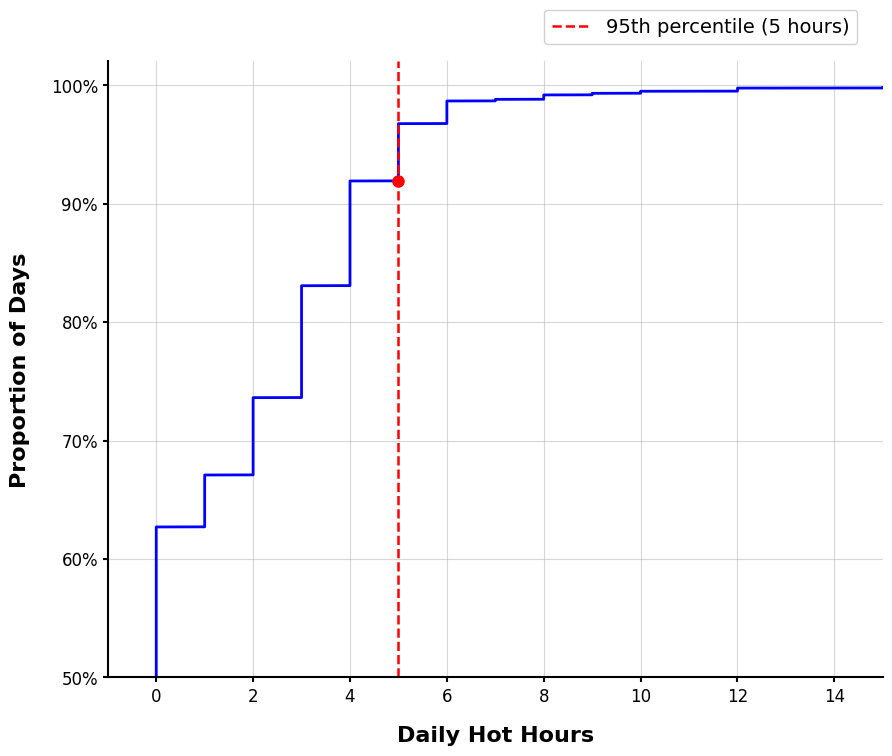

In [138]:
plot_precip_cdf(
    daily_hot_hours_214_eas,
    precip_col='Num_Hot_Hours',
    xlim=(-1, 15),
    ylim=(0.5,1.02),
    figsize=(10,8),
    linewidth=2,
    grid_alpha=0.5,
    xlabel='Daily Hot Hours',
    ylabel='Proportion of Days',
    x_ticks_size=12,
    y_ticks_size=12,
    x_label_weight='bold',
    y_label_weight='bold', 
    vlines=[
        {'x': 5, 'color':'r', 'linestyle':'--', 'label':'95th percentile (5 hours)'},
        # {'x': 6, 'color':'red', 'linestyle':':', 'label':'99th percentile - daily (6 hours)'}
    ], 
    legend_size=14,
    legend_loc='upper left', 
    legend_bbox=(0.55, 1.10), 
    marker_points=[5],  
    marker_colors=['r'],
    marker_style='o',
    marker_size=8,
    save_path='/home/kdonkor_umass_edu/Co-occurrence_Rev2/supplementary_plots/daily_temp.png'
)

### Daily Stats 

In [48]:
num_days_temp_95 = daily_hot_hours_214_eas[daily_hot_hours_214_eas['Num_Hot_Hours'] >= hot_hrs_thresh_dict['95']]
num_days_temp_99 = daily_hot_hours_214_eas[daily_hot_hours_214_eas['Num_Hot_Hours'] >= hot_hrs_thresh_dict['99']]

print(f"Total number of days is {len(daily_hot_hours_214_eas):,.0f}\n")
print(f"Number of days with temp >= 95th percentile is {len(num_days_temp_95):,.0f}")
print(f"Number of days with temp >= 99th percentile is {len(num_days_temp_99):,.0f}")

Total number of days is 155,254

Number of days with temp >= 95th percentile is 12,561
Number of days with temp >= 99th percentile is 5,047


In [49]:
percent_temp_days_95 = len(num_days_temp_95)*100/len(daily_hot_hours_214_eas)
percent_temp_days_95

8.09061280224664

## Wind CDF 

In [139]:
# plot_precip_cdf(
#     hourly_weather,
#     precip_col='Wind Gusts (m/s)',
#     xlim=(2.5, 20),
#     ylim=(0.65,1.02),
#     figsize=(10,8),
#     linewidth=2,
#     grid_alpha=0.5,
#     xlabel='Hourly Wind Gusts (m/s)',
#     ylabel='Proportion of Hours',
#     x_ticks_size=12,
#     y_ticks_size=12,
#     x_label_weight='bold',
#     y_label_weight='bold', 
#     vlines=[
#         {'x': 5.94, 'color':'blue', 'linestyle':'--', 'label':'95th percentile - hourly (5.94 m/s)'},
#         {'x': 7.08, 'color':'blue', 'linestyle':':', 'label':'99th percentile - hourly (7.08 m/s)'}, 
#         {'x': 11.18, 'color':'red', 'linestyle':'--', 'label':'Strong Breeze (11.18 m/s)'},
#         {'x': 14.30, 'color':'green', 'linestyle':':', 'label':'Near Gale (14.30 m/s)'},

#     ], 
#     legend_size=14,
#     legend_loc='upper left', 
#     legend_bbox=(0.70, 0.78), 
#     marker_points=[5.94, 7.08, 11.18, 14.30],  
#     marker_colors=['blue','blue', 'r', 'g'],
#     marker_style='o',
#     marker_size=8,
#     save_path='/home/kdonkor_umass_edu/Co-occurrence_Rev2/supplementary_plots/hourly_wind.png'
# )

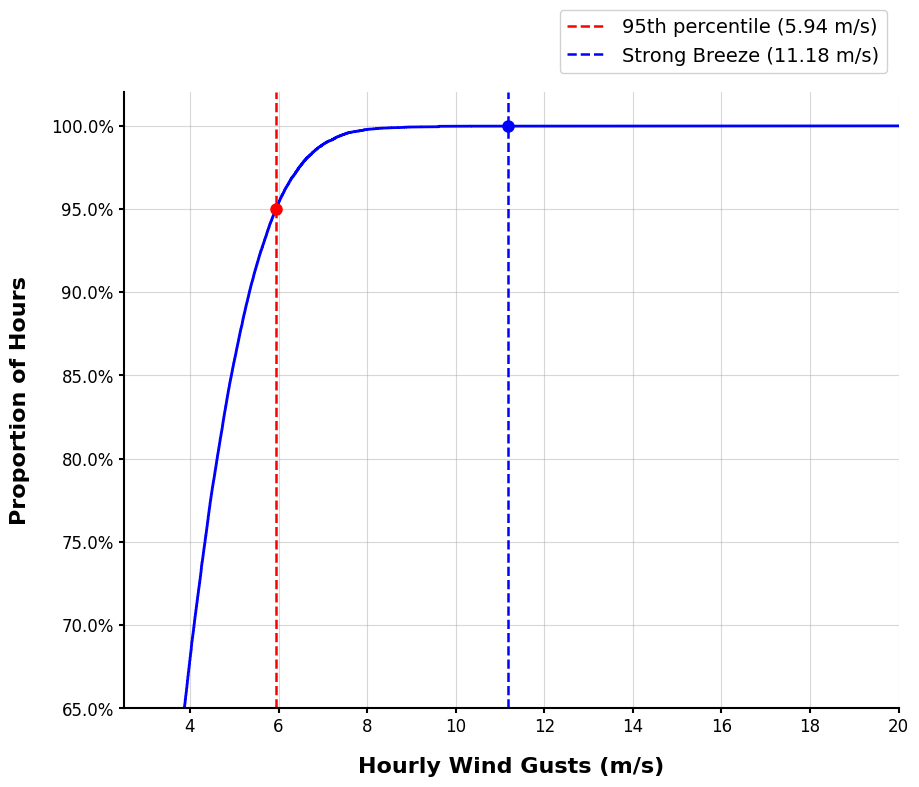

In [149]:
plot_precip_cdf(
    hourly_weather,
    precip_col='Wind Gusts (m/s)',
    xlim=(2.5, 20),
    ylim=(0.65,1.02),
    figsize=(10,8),
    linewidth=2,
    grid_alpha=0.5,
    xlabel='Hourly Wind Gusts (m/s)',
    ylabel='Proportion of Hours',
    x_ticks_size=12,
    y_ticks_size=12,
    x_label_weight='bold',
    y_label_weight='bold', 
    vlines=[
        {'x': 5.94, 'color':'red', 'linestyle':'--', 'label':'95th percentile (5.94 m/s)'},
        # {'x': 7.08, 'color':'blue', 'linestyle':':', 'label':'99th percentile - hourly (7.08 m/s)'}, 
        {'x': 11.18, 'color':'blue', 'linestyle':'--', 'label':'Strong Breeze (11.18 m/s)'},
        # {'x': 14.30, 'color':'green', 'linestyle':':', 'label':'Near Gale (14.30 m/s)'},

    ], 
    legend_size=14,
    legend_loc='upper left', 
    legend_bbox=(0.55, 1.15), 
    marker_points=[5.94, 11.18],  
    marker_colors=['red', 'blue'],
    marker_style='o',
    marker_size=8,
    save_path='/home/kdonkor_umass_edu/Co-occurrence_Rev2/supplementary_plots/hourly_wind.png'
)

### Hourly Stats 

In [51]:
num_hours_wind_95 = hourly_weather[hourly_weather['Wind Gusts (m/s)'] >= hourly_weather['Wind Gusts (m/s)'].quantile(0.95)]
num_hours_wind_99 = hourly_weather[hourly_weather['Wind Gusts (m/s)'] >= hourly_weather['Wind Gusts (m/s)'].quantile(0.99)]

num_hours_temp_strong_breeze = hourly_weather[hourly_weather['Wind Gusts (m/s)'] >= 11.18]
num_hours_temp_near_gale = hourly_weather[hourly_weather['Wind Gusts (m/s)'] >= 14.30]

In [52]:
print(f"Total number of hours is {len(hourly_weather):,.0f}\n")
print(f"Number of hours with wind gusts >= 95th percentile is {len(num_hours_wind_95):,.0f}")
print(f"Number of hours with wind gusts >= 99th percentile is {len(num_hours_wind_99):,.0f}")
print(f"Number of hours with wind gusts >= 11.18 m/s is {len(num_hours_temp_strong_breeze):,.0f}")
print(f"Number of hours with wind gusts >= 14.30 m/s is {len(num_hours_temp_near_gale):,.0f}")

Total number of hours is 4,092,070

Number of hours with wind gusts >= 95th percentile is 205,456
Number of hours with wind gusts >= 99th percentile is 41,148
Number of hours with wind gusts >= 11.18 m/s is 824
Number of hours with wind gusts >= 14.30 m/s is 571


In [53]:
percent_wind_hrs_strong_breeze = len(num_hours_temp_strong_breeze)*100/len(hourly_weather)
percent_wind_hrs_strong_breeze

0.02013650792875

### Daily 

In [54]:
wind_214_eas_df = hourly_weather.copy().drop(columns = ['Lightning Events', 'Precip', 'Temp'])

In [55]:
# Windy hour flag
wind_214_eas_df['Windy_Hour'] = wind_214_eas_df['Wind Gusts (m/s)'] > wind_thresh_dict['95']

# Group by EA and Date, and count Windy_Hour sum
daily_windy_hours_214_eas = (
    wind_214_eas_df.groupby(['ea_code9ch', 'Date'], as_index=False)
            .agg({'Windy_Hour': 'sum'})
)

daily_windy_hours_214_eas = daily_windy_hours_214_eas.rename(columns={'Windy_Hour': 'Num_Windy_Hours'})

In [150]:
# plot_precip_cdf(
#     daily_windy_hours_214_eas,
#     precip_col='Num_Windy_Hours',
#     xlim=(-0.5, 15),
#     ylim=(0.5,1.02),
#     figsize=(10,8),
#     linewidth=2,
#     grid_alpha=0.5,
#     xlabel='Daily Windy Hours',
#     ylabel='Proportion of Days',
#     x_ticks_size=12,
#     y_ticks_size=12,
#     x_label_weight='bold',
#     y_label_weight='bold', 
#     vlines=[
#         {'x': 6, 'color':'blue', 'linestyle':'--', 'label':'95th percentile - daily (6 hours)'},
#         {'x': 9, 'color':'red', 'linestyle':':', 'label':'99th percentile - daily (9 hours)'}
#     ], 
#     legend_size=14,
#     legend_loc='upper left', 
#     legend_bbox=(0.65, 0.78), 
#     marker_points=[6, 9],  
#     marker_colors=['blue', 'red'],
#     marker_style='o',
#     marker_size=8,
#     save_path='/home/kdonkor_umass_edu/Co-occurrence_Rev2/supplementary_plots/daily_wind.png'
# )

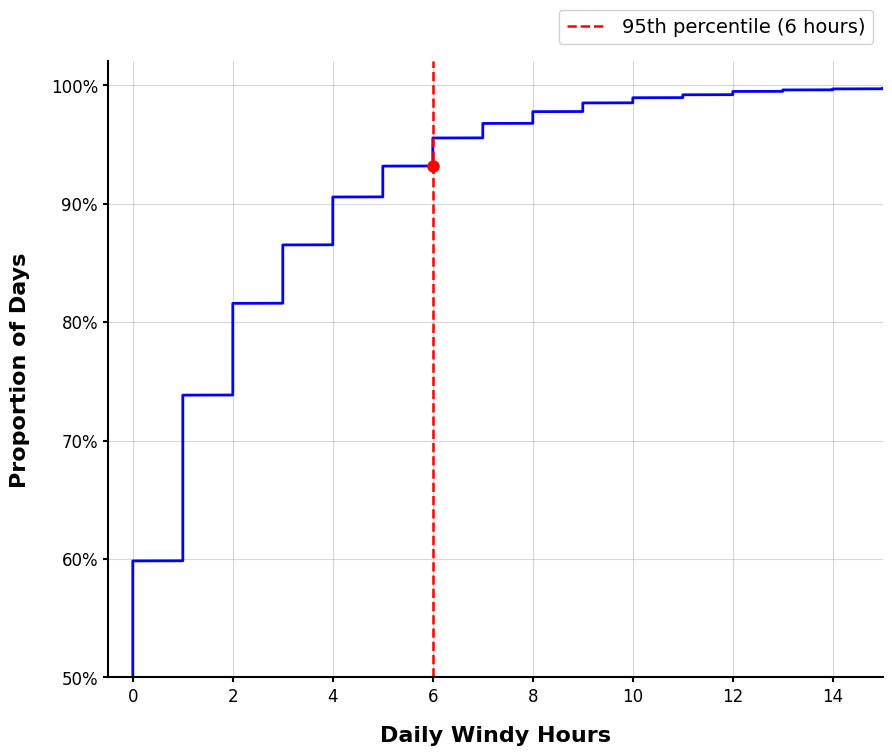

In [153]:
plot_precip_cdf(
    daily_windy_hours_214_eas,
    precip_col='Num_Windy_Hours',
    xlim=(-0.5, 15),
    ylim=(0.5,1.02),
    figsize=(10,8),
    linewidth=2,
    grid_alpha=0.5,
    xlabel='Daily Windy Hours',
    ylabel='Proportion of Days',
    x_ticks_size=12,
    y_ticks_size=12,
    x_label_weight='bold',
    y_label_weight='bold', 
    vlines=[
        {'x': 6, 'color':'red', 'linestyle':'--', 'label':'95th percentile (6 hours)'},
        # {'x': 9, 'color':'red', 'linestyle':':', 'label':'99th percentile - daily (9 hours)'}
    ], 
    legend_size=14,
    legend_loc='upper left', 
    legend_bbox=(0.57, 1.10), 
    marker_points=[6],  
    marker_colors=['red'],
    marker_style='o',
    marker_size=8,
    save_path='/home/kdonkor_umass_edu/Co-occurrence_Rev2/supplementary_plots/daily_wind.png'
)

### Daily Stats 

In [57]:
num_days_wind_95 = daily_windy_hours_214_eas[daily_windy_hours_214_eas['Num_Windy_Hours'] >= windy_hrs_thresh_dict['95']]
num_days_wind_99 = daily_windy_hours_214_eas[daily_windy_hours_214_eas['Num_Windy_Hours'] >= windy_hrs_thresh_dict['99']]

print(f"Total number of days is {len(daily_windy_hours_214_eas):,.0f}\n")
print(f"Number of days with wind >= 95th percentile is {len(num_days_wind_95):,.0f}")
print(f"Number of days with wind >= 99th percentile is {len(num_days_wind_99):,.0f}")

Total number of days is 155,254

Number of days with wind >= 95th percentile is 10,610
Number of days with wind >= 99th percentile is 3,474


In [58]:
percent_wind_days_95 = len(num_days_wind_95)*100/len(daily_windy_hours_214_eas)
percent_wind_days_95

6.833962409986216

### Bar plots  

### Thinking of showing `event hours` / `total hours` for each event  

In [59]:
print(f"Percentage of hours with temp >= thermal comfort = {percent_temp_hrs_therm_cmfrt:.2f}%")
print(f"Percentage of hours with lightning >= 1 event = {percent_hrs_lightning_1:.2f}%")
print(f"Percentage of hours with precip >= 'heavy rain' = {percent_precip_hrs_heavy_rain:.2f}%")
print(f"Percentage of hours with wind >=strong breeze = {percent_wind_hrs_strong_breeze:.2f}%")

Percentage of hours with temp >= thermal comfort = 5.84%
Percentage of hours with lightning >= 1 event = 0.69%
Percentage of hours with precip >= 'heavy rain' = 0.34%
Percentage of hours with wind >=strong breeze = 0.02%


In [60]:
def plot_extreme_weather_proportions(
    percent_wind_days_95,
    percent_lightning_days_95,
    percent_precip_days_95,
    percent_temp_days_95,
    figsize=(8, 6)
):
    # Round values to 1 decimal place
    values = [
        round(percent_wind_days_95, 1),
        round(percent_lightning_days_95, 1),
        round(percent_precip_days_95, 1),
        round(percent_temp_days_95, 1),
    ]
    
    labels = ['W', 'L', 'P', 'T']

    fig, ax = plt.subplots(figsize=figsize)
    ax.barh(labels, values)

    ax.set_xlabel('Proportion of days (%)')
    ax.set_ylabel('Weather Variable')

    # Annotate bars with values
    for i, v in enumerate(values):
        ax.text(v, i, f'{v}%', va='center')

    plt.tight_layout()
    plt.show()

In [61]:
# plot_extreme_weather_proportions(
#     percent_wind_days_95,
#     percent_temp_days_95,
#     percent_lightning_days_95,
#     percent_precip_days_95,
#     figsize=(6, 4)
# )

In [62]:
percent_wind_hrs_strong_breeze
percent_temp_hrs_therm_cmfrt
percent_hrs_lightning_1
percent_precip_hrs_heavy_rain

0.3444955731451319

In [63]:
# plot_extreme_weather_proportions(
#     percent_wind_days_95,
#     percent_temp_days_95,
#     percent_lightning_days_95,
#     percent_precip_days_95,
#     figsize=(6, 4)
# )

## Outage Stats 

In [64]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

def plot_cdf(
    df,
    column='dur_hr',
    xlim=None,
    ylim=None,
    figsize=(10, 8),
    xlabel=None,
    x_axis_pct_format = False, 
    ylabel='Proportion of hours (%)',
    vlines=None,
    legend_size=14,
    legend_loc='best',
    legend_bbox=(1.0, 1.0),
    save_path=None   # NEW
):
    
    # Extract values
    values = df[column].dropna().values
    
    # Sort values
    x = np.sort(values)
    
    # Compute CDF
    y = np.arange(1, len(x) + 1) / len(x)
    
    # Plot
    fig, ax = plt.subplots(figsize=figsize)
    ax.plot(x, y, lw=2.5, color='blue')
    
    # Labels
    ax.set_xlabel(xlabel if xlabel else column, fontsize=16, fontweight='bold', labelpad=15)
    ax.set_ylabel(ylabel, fontsize=16, fontweight='bold', labelpad=15)
    
    # Tick size
    ax.tick_params(axis='both', labelsize=13)
    
    # Percent y-axis
    ax.yaxis.set_major_formatter(PercentFormatter(xmax=1))

    if x_axis_pct_format:
        ax.xaxis.set_major_formatter(PercentFormatter(xmax=100))
    
    # Limits
    if xlim:
        ax.set_xlim(xlim)
    
    if ylim:
        ax.set_ylim(ylim)
        
    # --- Vertical lines + text + intersection dots ---
    if vlines:
        for line in vlines:
            x_val = line.get('x')
            
            ax.axvline(
                x=x_val,
                color=line.get('color', 'black'),
                linestyle=line.get('linestyle', '--'),
                linewidth=line.get('linewidth', 1.8),
                label=line.get('label')
            )
            
            idx = np.abs(x - x_val).argmin()
            y_val = y[idx]
            
            ax.plot(
                x[idx],
                y_val,
                marker='o',
                color=line.get('color', 'black'),
                markersize=line.get('marker_size', 7),
                zorder=5
            )
            
            if 'text' in line:
                ax.text(
                    x_val,
                    line.get('text_y', 0.9),
                    line['text'],
                    color=line.get('color', 'black'),
                    fontsize=line.get('text_size', 12),
                    rotation=line.get('text_rotation', 90),
                    ha=line.get('ha', 'right'),
                    va=line.get('va', 'center')
                )
    
    # Legend
    handles, labels = ax.get_legend_handles_labels()
    if labels:
        ax.legend(
            fontsize=legend_size,
            loc=legend_loc,
            bbox_to_anchor=legend_bbox,
            frameon=True,
            framealpha=0.9
        )
    
    # Spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # Grid
    ax.grid(True, linestyle='--', alpha=0.5)
    
    plt.tight_layout()
    
    # SAVE FIGURE
    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches='tight')
    
    plt.show()

In [65]:
## 22 
pqr_hourly_22 = pd.read_csv('/work/pi_jtaneja_umass_edu/kdonkor_umass_edu/Geospatial_Files/2022/merged_outage_n_voltage_hourly_22_NEW.csv')
pqr_hourly_22['time'] = pd.to_datetime(pqr_hourly_22['time'])
pqr_hourly_22['time'] = pqr_hourly_22['time'].dt.tz_convert(None)

## 23 
pqr_hourly_23 = pd.read_csv('/work/pi_jtaneja_umass_edu/kdonkor_umass_edu/Geospatial_Files/2023/merged_outage_n_voltage_hourly_23_NEW.csv')
pqr_hourly_23['time'] = pd.to_datetime(pqr_hourly_23['time'])
pqr_hourly_23['time'] = pqr_hourly_23['time'].dt.tz_convert(None)

pqr_hourly_all = pd.concat([pqr_hourly_22, pqr_hourly_23], ignore_index=True).drop(columns=['Unnamed: 0'])
pqr_hourly_all = pqr_hourly_all[pqr_hourly_all['site_id'] != 0].reset_index(drop=True)[['time', 'site_id', 'outage_events', 'outage_mins']]

In [66]:
pqr_hourly_all_filt = pqr_hourly_all[pqr_hourly_all['outage_events']>0].reset_index(drop=True)

pqr_hourly_all_filt['outage_hrs'] = pqr_hourly_all_filt['outage_mins']/60
pqr_hourly_all_filt[["outage_hrs", "outage_mins"]] = (pqr_hourly_all_filt[["outage_hrs", "outage_mins"]].round(2))

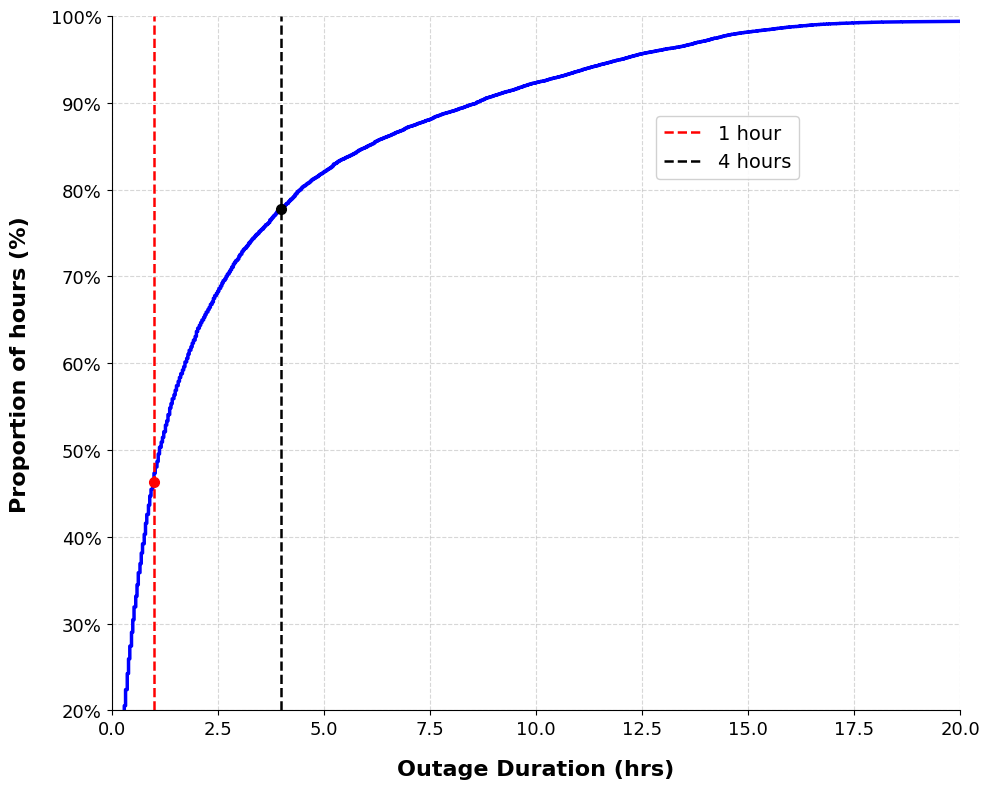

In [67]:
plot_cdf(
    pqr_hourly_all_filt,
    column='outage_hrs',
    xlim=(0, 20),
    ylim=(0.2, 1),
    xlabel='Outage Duration (hrs)',
    legend_loc='upper left',
    legend_bbox=(0.63, 0.87), 
        vlines=[
        {'x': 1, 'color': 'r', 'label': '1 hour'},
        {'x': 4, 'color': 'k', 'label': '4 hours'},
    ],
    save_path='/home/kdonkor_umass_edu/Co-occurrence_Rev2/supplementary_plots/outage_duration_site_level_cdf.png'
)

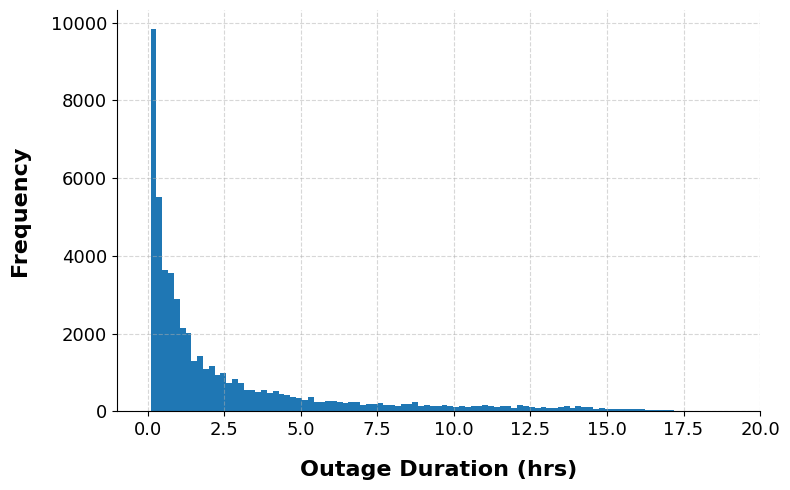

In [68]:
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

fig, ax = plt.subplots(figsize=(8, 5)) 

ax.hist(pqr_hourly_all_filt['outage_hrs'], bins=200)

# Labels
ax.set_xlabel('Outage Duration (hrs)', labelpad=15, fontsize=16, fontweight = 'bold')
ax.set_ylabel('Frequency', labelpad=15, fontsize=16, fontweight = 'bold')

# Tick size (both axes)
ax.tick_params(axis='both', labelsize=13)

# Hide top & right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.set_xlim(-1, 20)

# Grid
ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()

# Save figure
fig.savefig('/home/kdonkor_umass_edu/Co-occurrence_Rev2/supplementary_plots/outage_hours_site_level_hist.png', dpi=300, bbox_inches='tight')

plt.show()